# DESS66x8 Analysis

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import openmm as mm
import pandas as pd
import seaborn as sns
import torch
from emle.models import EMLE
from openff.interchange import Interchange
from openff.toolkit import ForceField, Molecule, Topology
from rdkit import Chem
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)

ANGSTROM_TO_BOHR = 1.8897259886
HARTREE_TO_KJ_MOL = 2625.5002
NM_TO_BOHR = 18.897259886
KCAL_TO_KJ = 4.184
atomic_number = {"H": 1, "C": 6, "N": 7, "O": 8, "S": 16}

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

### Configuration

In [3]:
DESS66X8_FILE = "DESS66x8.csv"
EMLE_REF_MODEL = "../../emle_models/ligand_patched_static_only.mat"
EMLE_FIT_MODEL = "../../training/02_fit_xdm_moments_reference/ligand_patched_static_only_xdm.mat"

### OpenFF-2.0.0 force field

Used below by `get_off_params` to derive per-atom (sigma, epsilon) parameters for each monomer SMILES.

In [4]:
force_field = ForceField("openff-2.0.0.offxml")

### EMLE/XDM per-atom LJ parameters

Isotropic polarizabilities from the reference EMLE model, $C_6$ from the model trained with `dispersion_mode="c6"`.

In [5]:
emle_ref = EMLE(
    model=EMLE_REF_MODEL, device=device, dtype=dtype, alpha_mode="reference"
)
emle_base_ref = emle_ref._emle_base

emle_fit = EMLE(model=EMLE_FIT_MODEL, device=device, dtype=dtype, dispersion_mode="c6")
emle_base_fit = emle_fit._emle_base


def emle_xdm_lj_params(z_batch, xyz_batch, q_mol_batch):
    """Per-atom (sigma [Bohr], epsilon [kJ/mol], alpha [Bohr^3], m1_pred) from EMLE polarizabilities and fitted XDM C6."""
    _, _, _, A_thole, *_ = emle_base_ref.forward(
        z_batch, xyz_batch, q_mol_batch, calc_A_thole=True, calc_c6=False
    )
    alpha = emle_base_ref.get_isotropic_polarizabilities_thole(A_thole.detach())
    alpha = alpha * (z_batch > 0)

    _, _, _, _, c6_pred, *_ = emle_base_fit.forward(
        z_batch, xyz_batch, q_mol_batch, calc_A_thole=True, calc_c6=True
    )

    c6_val = 0.5 * c6_pred * alpha
    rmin = 2 * (2.54 * alpha ** (1 / 7))
    sigma = rmin / (2 ** (1 / 6))
    epsilon = c6_val / (4 * sigma**6 + 1e-16) * HARTREE_TO_KJ_MOL
    return sigma, epsilon, alpha, c6_pred

### Pairwise Lennard-Jones energies

In [6]:
def lj_pair_energies(xyz_i, xyz_j, sigma_i, epsilon_i, sigma_j, epsilon_j, z_i, z_j):
    """Total 12-6 LJ repulsive/attractive energies (kJ/mol) summed over all valid QM-MM atom pairs."""
    r = torch.cdist(xyz_i, xyz_j) * ANGSTROM_TO_BOHR + 1e-16
    sigma_ij = 0.5 * (sigma_i.unsqueeze(2) + sigma_j.unsqueeze(1))
    epsilon_ij = torch.sqrt(epsilon_i.unsqueeze(2) * epsilon_j.unsqueeze(1) + 1e-16)

    sr6 = (sigma_ij / r) ** 6
    e_rep = 4.0 * epsilon_ij * sr6**2
    e_att = -4.0 * epsilon_ij * sr6

    mask = (z_i > 0).unsqueeze(2) & (z_j > 0).unsqueeze(1)
    zero = torch.zeros((), device=e_rep.device, dtype=e_rep.dtype)
    e_rep = torch.where(mask, e_rep, zero).sum(dim=(1, 2))
    e_att = torch.where(mask, e_att, zero).sum(dim=(1, 2))
    return e_rep, e_att

## DESS66x8 Systems

In [7]:
def ordered_rdkit_mol(smiles):
    params = Chem.SmilesParserParams()
    params.removeHs = False
    rd_mol = Chem.MolFromSmiles(smiles, params)
    rd_mol = Chem.AddHs(rd_mol)
    map_nums = [a.GetAtomMapNum() for a in rd_mol.GetAtoms()]
    if any(m > 0 for m in map_nums):
        rd_mol = Chem.RenumberAtoms(
            rd_mol, sorted(range(rd_mol.GetNumAtoms()), key=lambda i: map_nums[i])
        )
    for a in rd_mol.GetAtoms():
        a.SetAtomMapNum(0)
    return rd_mol


_off_param_cache = {}


def get_off_params(smiles):
    if smiles in _off_param_cache:
        return _off_param_cache[smiles]

    rd_mol = ordered_rdkit_mol(smiles)
    z_np = np.array(
        [atomic_number[a.GetSymbol()] for a in rd_mol.GetAtoms()], dtype=np.int64
    )

    off_mol = Molecule.from_rdkit(rd_mol, allow_undefined_stereo=True)
    off_mol.generate_conformers(n_conformers=1)
    interchange = Interchange.from_smirnoff(
        force_field, Topology.from_molecules([off_mol])
    )
    omm_system = interchange.to_openmm()
    nonbonded = next(
        f for f in omm_system.getForces() if isinstance(f, mm.NonbondedForce)
    )

    sigma_np, epsilon_np = [], []
    for i in range(nonbonded.getNumParticles()):
        _, sigma_nm, epsilon_kj = nonbonded.getParticleParameters(i)
        sigma_np.append(sigma_nm.value_in_unit(mm.unit.nanometer) * NM_TO_BOHR)
        epsilon_np.append(epsilon_kj.value_in_unit(mm.unit.kilojoule_per_mole))

    result = (z_np, np.array(sigma_np), np.array(epsilon_np))
    _off_param_cache[smiles] = result
    return result


In [8]:
df_s66x8 = pd.read_csv(DESS66X8_FILE)

records = []
grid_data = {}

for system_name, group in df_s66x8.groupby("system_name", sort=False):
    sub_sys = group.sort_values("k_index").reset_index(drop=True)
    n_sys = len(sub_sys)
    natoms0_sys = int(sub_sys.iloc[0]["natoms0"])
    natoms1_sys = int(sub_sys.iloc[0]["natoms1"])

    xyz_qm_sys = np.stack(
        [
            np.fromstring(r["xyz"], sep=" ").reshape(-1, 3)[:natoms0_sys]
            for _, r in sub_sys.iterrows()
        ]
    )
    xyz_mm_sys = np.stack(
        [
            np.fromstring(r["xyz"], sep=" ").reshape(-1, 3)[natoms0_sys:]
            for _, r in sub_sys.iterrows()
        ]
    )
    # Closest QM-MM atom-atom contact per frame (Angstrom), for filtering out close-range geometries.
    min_dist_sys = (
        np.linalg.norm(xyz_qm_sys[:, :, None, :] - xyz_mm_sys[:, None, :, :], axis=-1)
        .reshape(n_sys, -1)
        .min(axis=1)
    )

    z0_np, sigma0_np, epsilon0_np = get_off_params(sub_sys.iloc[0]["smiles0"])
    z1_np, sigma1_np, epsilon1_np = get_off_params(sub_sys.iloc[0]["smiles1"])
    assert len(z0_np) == natoms0_sys and len(z1_np) == natoms1_sys, (
        f"atom count mismatch for {system_name}"
    )

    z_sys = (
        torch.tensor(z0_np, device=device, dtype=torch.long)
        .unsqueeze(0)
        .expand(n_sys, -1)
    )
    z_mm_sys = (
        torch.tensor(z1_np, device=device, dtype=torch.long)
        .unsqueeze(0)
        .expand(n_sys, -1)
    )
    xyz_qm_sys_t = torch.tensor(xyz_qm_sys, device=device, dtype=dtype)
    xyz_mm_sys_t = torch.tensor(xyz_mm_sys, device=device, dtype=dtype)
    q_mol_sys = torch.zeros(n_sys, device=device, dtype=dtype)

    sigma_qm_off_sys = (
        torch.tensor(sigma0_np, device=device, dtype=dtype)
        .unsqueeze(0)
        .expand(n_sys, -1)
    )
    epsilon_qm_off_sys = (
        torch.tensor(epsilon0_np, device=device, dtype=dtype)
        .unsqueeze(0)
        .expand(n_sys, -1)
    )
    sigma_mm_off_sys = (
        torch.tensor(sigma1_np, device=device, dtype=dtype)
        .unsqueeze(0)
        .expand(n_sys, -1)
    )
    epsilon_mm_off_sys = (
        torch.tensor(epsilon1_np, device=device, dtype=dtype)
        .unsqueeze(0)
        .expand(n_sys, -1)
    )

    with torch.no_grad():
        sigma_qm_fit_sys, epsilon_qm_fit_sys, alpha_qm_sys, m1_qm_sys = (
            emle_xdm_lj_params(z_sys, xyz_qm_sys_t, q_mol_sys)
        )
        sigma_mm_fit_sys, epsilon_mm_fit_sys, alpha_mm_sys, m1_mm_sys = (
            emle_xdm_lj_params(z_mm_sys, xyz_mm_sys_t, q_mol_sys)
        )

        e_rep_off_sys, e_att_off_sys = lj_pair_energies(
            xyz_qm_sys_t,
            xyz_mm_sys_t,
            sigma_qm_off_sys,
            epsilon_qm_off_sys,
            sigma_mm_off_sys,
            epsilon_mm_off_sys,
            z_sys,
            z_mm_sys,
        )
        e_rep_fit_sys, e_att_fit_sys = lj_pair_energies(
            xyz_qm_sys_t,
            xyz_mm_sys_t,
            sigma_qm_fit_sys,
            epsilon_qm_fit_sys,
            sigma_mm_fit_sys,
            epsilon_mm_fit_sys,
            z_sys,
            z_mm_sys,
        )

    e_rep_off_sys = e_rep_off_sys.cpu().numpy()
    e_att_off_sys = e_att_off_sys.cpu().numpy()
    e_rep_fit_sys = e_rep_fit_sys.cpu().numpy()
    e_att_fit_sys = e_att_fit_sys.cpu().numpy()

    sapt_ex_sys = sub_sys["sapt_ex"].to_numpy() * KCAL_TO_KJ
    e_disp_sys = (
        sub_sys["sapt_disp"] + sub_sys["sapt_exdisp_os"] + sub_sys["sapt_exdisp_ss"]
    ).to_numpy() * KCAL_TO_KJ

    e_lj_off_full_sys = e_rep_off_sys + e_att_off_sys
    e_lj_fit_full_sys = e_rep_fit_sys + e_att_fit_sys
    e_sapt_full_sys = sapt_ex_sys + e_disp_sys

    grid_data[system_name] = dict(
        k_index=sub_sys["k_index"].to_numpy(),
        sapt_ex=sapt_ex_sys,
        e_rep_off=e_rep_off_sys,
        e_rep_fit=e_rep_fit_sys,
        e_disp=e_disp_sys,
        e_att_off=e_att_off_sys,
        e_att_fit=e_att_fit_sys,
        e_sapt_full=e_sapt_full_sys,
        e_lj_off_full=e_lj_off_full_sys,
        e_lj_fit_full=e_lj_fit_full_sys,
        min_dist=min_dist_sys,
    )

    for i in range(n_sys):
        records.append(
            dict(
                system_name=system_name,
                k_index=int(sub_sys.iloc[i]["k_index"]),
                sapt_ex=sapt_ex_sys[i],
                e_rep_off=e_rep_off_sys[i],
                e_rep_fit=e_rep_fit_sys[i],
                e_disp=e_disp_sys[i],
                e_att_off=e_att_off_sys[i],
                e_att_fit=e_att_fit_sys[i],
                e_sapt_full=e_sapt_full_sys[i],
                e_lj_off_full=e_lj_off_full_sys[i],
                e_lj_fit_full=e_lj_fit_full_sys[i],
                min_dist=min_dist_sys[i],
            )
        )

results_df = pd.DataFrame.from_records(records)
print(
    f"Computed {len(results_df)} frames across {results_df['system_name'].nunique()} S66x8 systems"
)

Computed 528 frames across 66 S66x8 systems


In [9]:
def regression_stats(ref, pred):
    rmse = np.sqrt(mean_squared_error(ref, pred))
    mae = mean_absolute_error(ref, pred)
    return rmse, mae


def plot_parity(ax, ref, pred, title, color, label, view_lims=None):
    rmse, mae = regression_stats(ref, pred)
    lims = (
        list(view_lims)
        if view_lims is not None
        else [min(ref.min(), pred.min()), max(ref.max(), pred.max())]
    )
    full_label = f"{label} (RMSE={rmse:.2f}, MAE={mae:.2f})"
    ax.scatter(
        ref, pred, s=12, alpha=0.5, color=color, edgecolor="none", label=full_label
    )
    ax.plot(lims, lims, color="k", ls="--", lw=1)
    if view_lims is not None:
        ax.set_xlim(lims)
        ax.set_ylim(lims)
    ax.set_xlabel(r"SAPT [kJ.mol$^{-1}$]")
    ax.set_ylabel(r"Prediction [kJ.mol$^{-1}$]")
    if title:
        ax.set_title(title)

### Selected systems

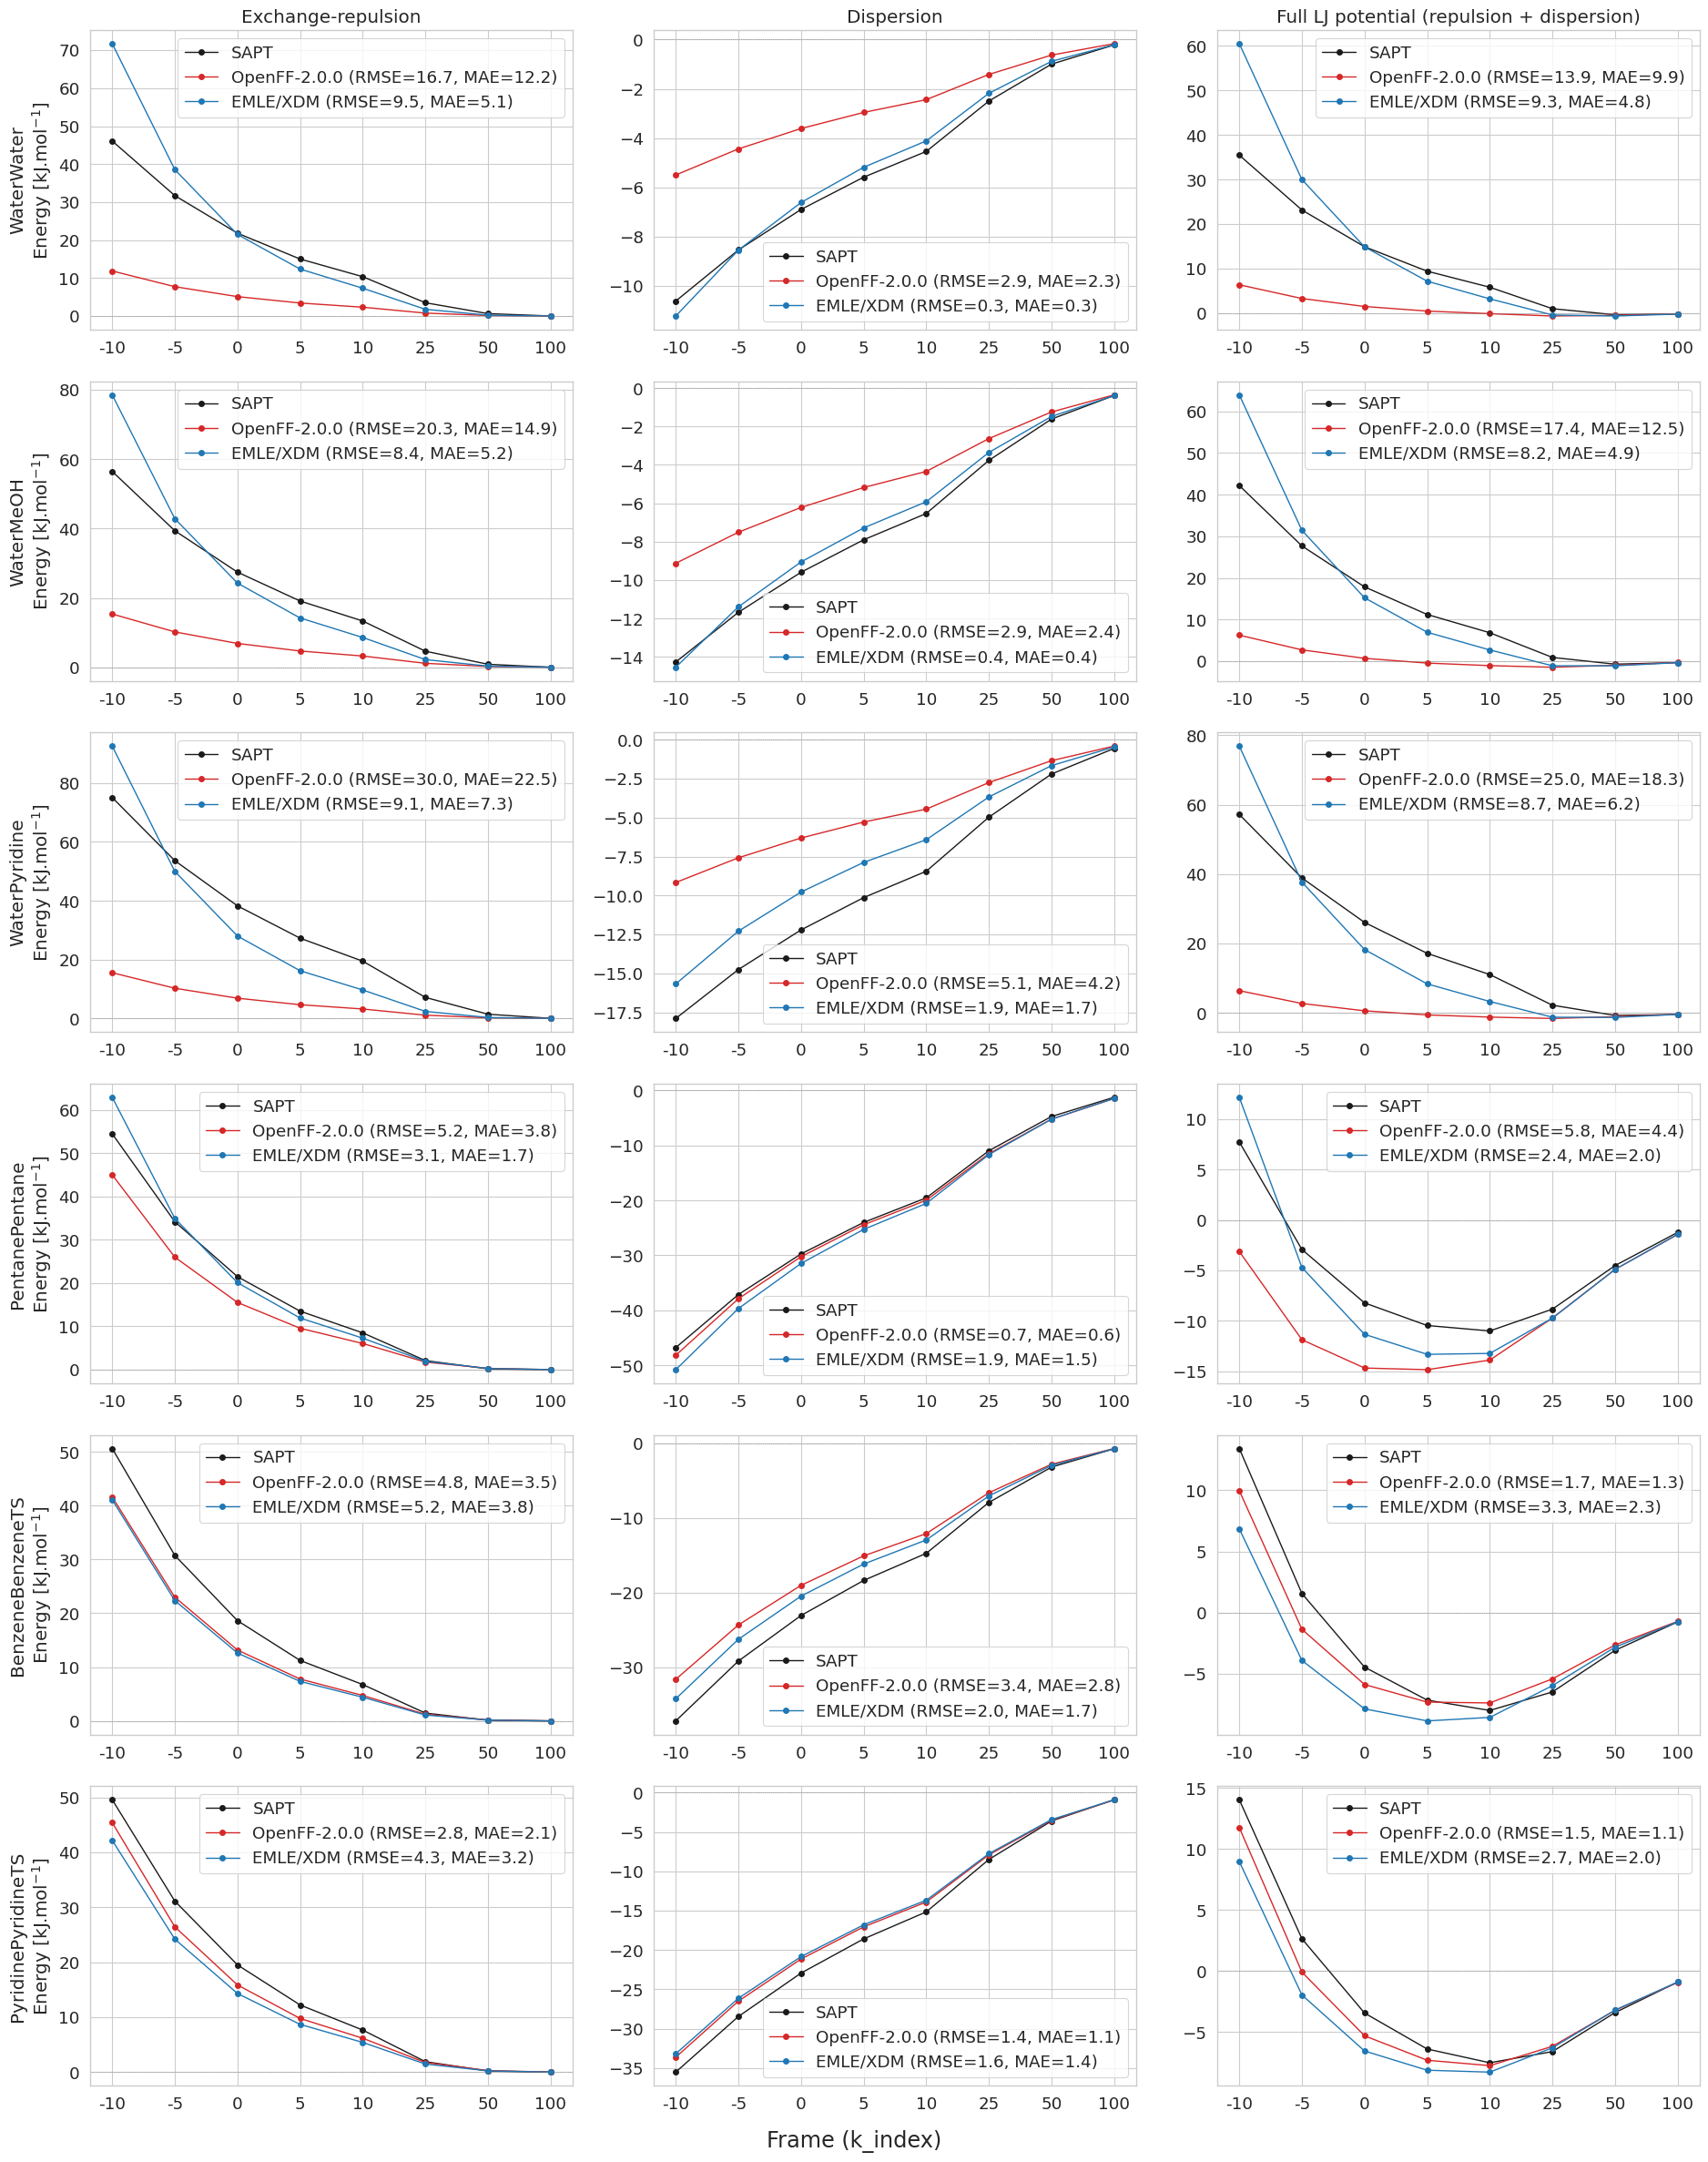

In [16]:
def plot_component_grid(system_names, filename):
    """Rows = systems, columns = exchange-repulsion / dispersion / full LJ potential vs. frame."""
    nrows = len(system_names)
    fig, axes = plt.subplots(nrows, 3, figsize=(19, 4* nrows), squeeze=False)

    col_specs = [
        ("sapt_ex", "e_rep_off", "e_rep_fit", "Exchange-repulsion"),
        ("e_disp", "e_att_off", "e_att_fit", "Dispersion"),
        (
            "e_sapt_full",
            "e_lj_off_full",
            "e_lj_fit_full",
            "Full LJ potential (repulsion + dispersion)",
        ),
    ]

    for row, system_name in enumerate(system_names):
        d = grid_data[system_name]
        frame_sys = np.arange(len(d["k_index"]))
        for col, (ref_key, off_key, fit_key, col_title) in enumerate(col_specs):
            ax = axes[row, col]
            rmse_off = np.sqrt(np.mean((d[off_key] - d[ref_key]) ** 2))
            rmse_fit = np.sqrt(np.mean((d[fit_key] - d[ref_key]) ** 2))
            ax.plot(frame_sys, d[ref_key], "o-", color="k", ms=4, lw=1, label="SAPT")
            ax.plot(
                frame_sys,
                d[off_key],
                "o-",
                color="tab:red",
                ms=4,
                lw=1,
                label=f"OpenFF-2.0.0 (RMSE={rmse_off:.1f}, MAE={np.mean(np.abs(d[off_key] - d[ref_key])):.1f})",
            )
            ax.plot(
                frame_sys,
                d[fit_key],
                "o-",
                color="tab:blue",
                ms=4,
                lw=1,
                label=f"EMLE/XDM (RMSE={rmse_fit:.1f}, MAE={np.mean(np.abs(d[fit_key] - d[ref_key])):.1f})",
            )
            ax.axhline(0, color="gray", lw=0.5, ls=":")
            ax.set_xticks(frame_sys)
            ax.set_xticklabels(d["k_index"])
            ax.legend(loc="best")
            if row == 0:
                ax.set_title(col_title)
            if col == 0:
                ax.set_ylabel(
                    system_name.split("_", 1)[1] + "\n" + r"Energy [kJ.mol$^{-1}$]",
                )

    fig.supxlabel("Frame (k_index)")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")


plot_component_grid(
    [
        "1_WaterWater",
        "2_WaterMeOH",
        "18_WaterPyridine",
        "34_PentanePentane",
        "47_BenzeneBenzeneTS",
        "48_PyridinePyridineTS",
    ],
    "des_selected_systems.pdf",
)

In [11]:
def plot_parity_triplet(df_subset, title, filename):
    """1x3 parity-plot row (exchange-repulsion, dispersion, full LJ potential) over `df_subset`."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    col_specs = [
        ("sapt_ex", "e_rep_off", "e_rep_fit", "Exchange-repulsion"),
        ("e_disp", "e_att_off", "e_att_fit", "Dispersion"),
        (
            "e_sapt_full",
            "e_lj_off_full",
            "e_lj_fit_full",
            "Full LJ potential (repulsion + dispersion)",
        ),
    ]

    for ax, (ref_key, off_key, fit_key, col_title) in zip(axes, col_specs):
        plot_parity(
            ax,
            df_subset[ref_key].to_numpy(),
            df_subset[off_key].to_numpy(),
            col_title,
            "tab:red",
            "OpenFF-2.0.0",
        )
        plot_parity(
            ax,
            df_subset[ref_key].to_numpy(),
            df_subset[fit_key].to_numpy(),
            None,
            "tab:blue",
            "EMLE/XDM",
        )
        ax.legend()

    fig.suptitle(title, y=1.03)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")

### Full DESS66x8 dataset — parity plots

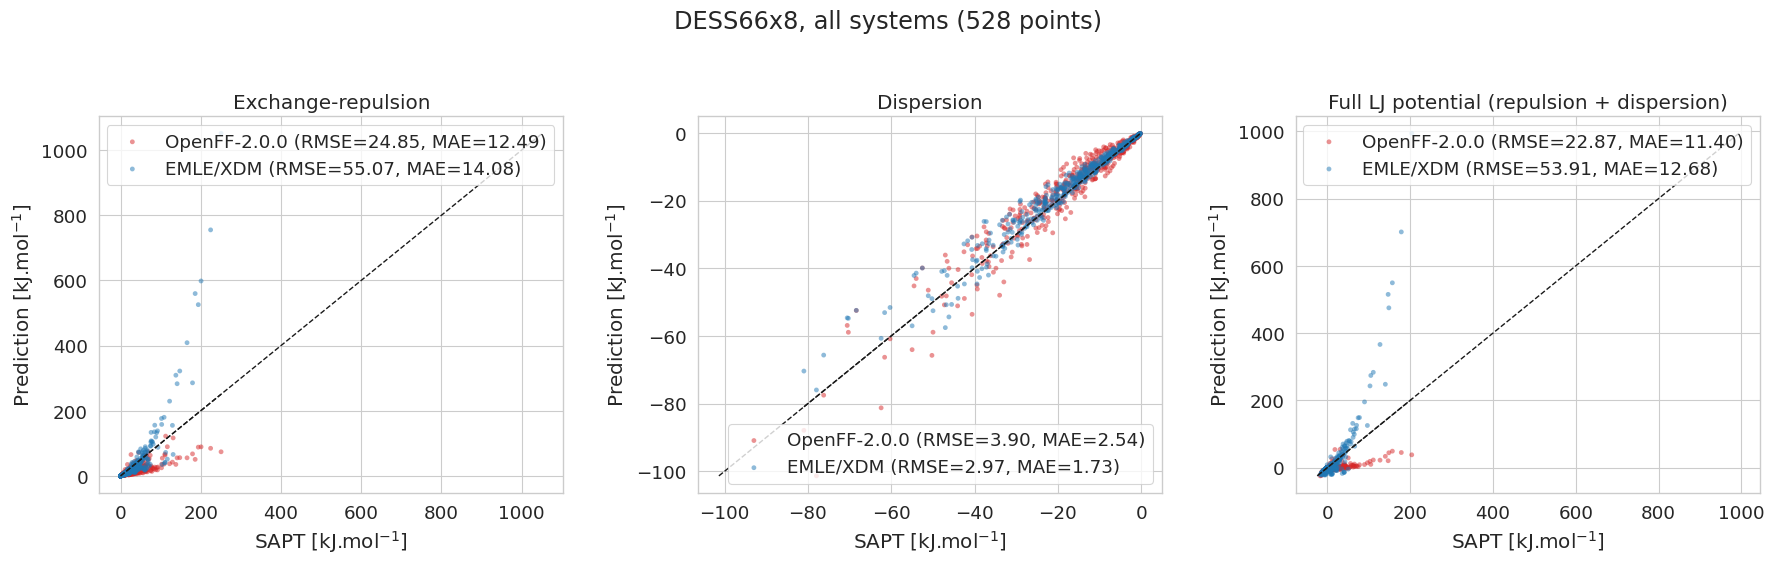

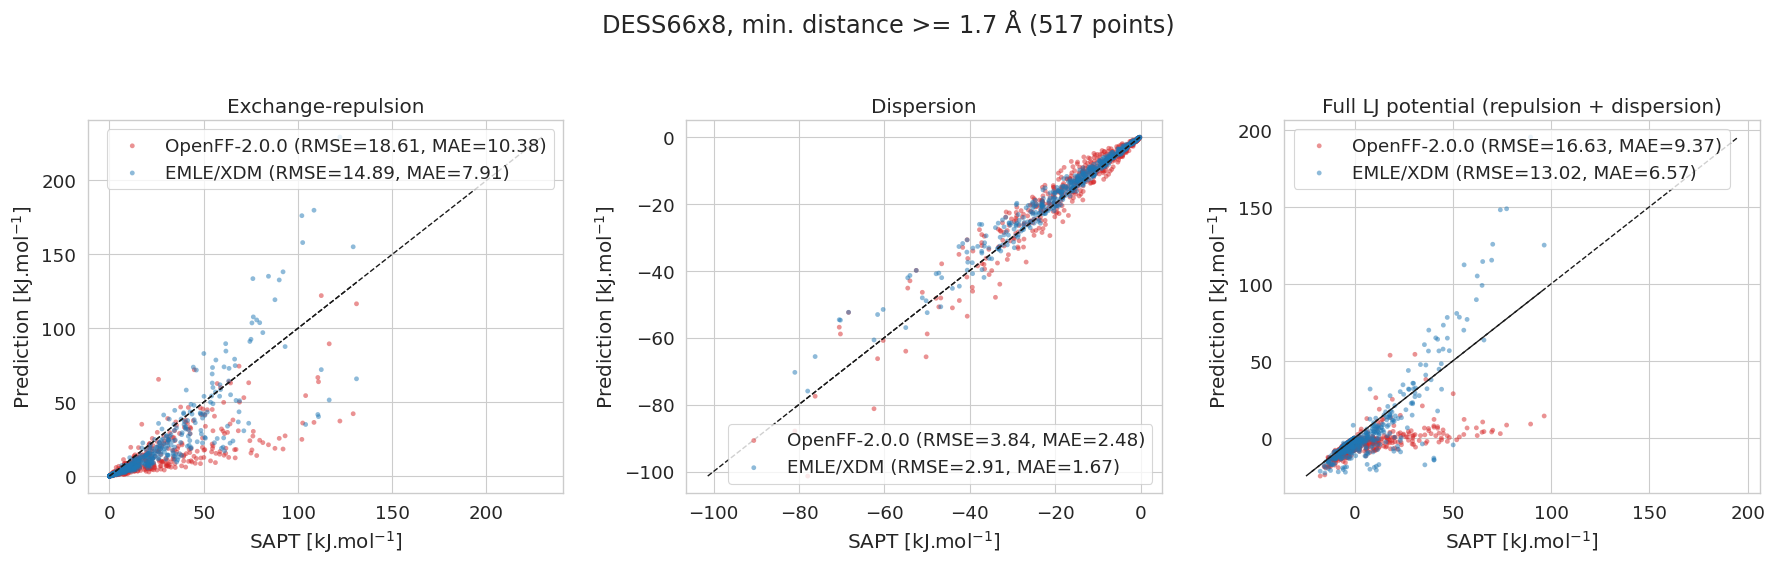

In [12]:
MIN_DIST_THRESHOLD = 1.7 # Angstrom

results_df_far = results_df[results_df["min_dist"] >= MIN_DIST_THRESHOLD]

plot_parity_triplet(
    results_df,
    f"DESS66x8, all systems ({len(results_df)} points)",
    "des_analysis.pdf",
)
plot_parity_triplet(
    results_df_far,
    f"DESS66x8, min. distance >= {MIN_DIST_THRESHOLD} \u00c5 "
    f"({len(results_df_far)} points)",
    "des_analysis_min_dist.pdf",
)